In [1]:
import os
import json
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as functional
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

/Users/lorenaandravacarean/Desktop/Fake News/Model/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/lorenaandravacarean/Desktop/Fake News/Model/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "roberta-base"
LABELS = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

In [3]:
LABEL2ID

{'SUPPORTS': 0, 'REFUTES': 1, 'NOT ENOUGH INFO': 2}

In [4]:
ID2LABEL

{0: 'SUPPORTS', 1: 'REFUTES', 2: 'NOT ENOUGH INFO'}

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [6]:
device

device(type='mps')

### Helper functions to load datasets

In [7]:
import pandas as pd

In [8]:
def load_multifc_claims(path_):
    data_list = []
    df = pd.read_json(path_, lines=True)
    
    for idx, row in df.iterrows():
        claim_text = row["claim"]
        label_str = row["label"]
        label_id = LABEL2ID.get(label_str)
        
        data_list.append({
            "claim": claim_text,
            "label_id": label_id
        })

    return data_list

In [9]:
def load_fever_claims(path_):
    data_list = []
    df = pd.read_json(path_, lines=True)

    for idx, row in df.iterrows():
        claim_text = row["claim"]
        evidence_text = row.get("evidence_text", "")
        label_str = row["label"]
        label_id = LABEL2ID.get(label_str)
        data_list.append({
            "claim": claim_text,
            "evidence": evidence_text,
            "label_id": label_id
        })
    
    return data_list

## Dataset Classes

### Claim-Only (MultiFC)

In [9]:
class MultiFCDataset(Dataset):
    
    def __init__(self, data_list, tokenizer, max_len=128):
        self.data_list = data_list
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        sample = self.data_list[idx]
        claim_text = sample["claim"]
        label_id = sample["label_id"]

        encoded = self.tokenizer(
            text=claim_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        # return item only (from (1, max_len) to (max_len))
        input_ids = encoded["input_ids"].squeeze(0)
        attn_mask = encoded["attention_mask"].squeeze(0)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "label": torch.tensor(label_id, dtype=torch.long)
        }

### Claim + Evidence (FEVER)

In [11]:
class FeverDataset(Dataset):

    def __init__(self, data_list, tokenizer, max_len=256):
        self.data_list = data_list
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        sample = self.data_list[idx]
        claim_text = sample["claim"]
        evidence_text = sample["evidence"]
        label_id = sample["label_id"]

        encoded = self.tokenizer(
            text=claim_text,
            text_pair=evidence_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attn_mask = encoded["attention_mask"].squeeze(0)

        return {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "label": torch.tensor(label_id, dtype=torch.long)
        }

## Model

In [10]:
class BiGRUCNNClassifier(nn.Module):

    def __init__(self, roberta_name="roberta-base", hidden_size=128, num_labels=3):
        super().__init__()
        # STEP 1: load RoBERTa as the encoder
        self.roberta = AutoModel.from_pretrained(roberta_name)

        # STEP 2: BiGRU
        # roberta output: 768 dimensional embeddings
        self.gru = nn.GRU(
            input_size=768,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # STEP 3: CNN
        self.conv1 = nn.Conv1d(
            in_channels=2*hidden_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1
        )

        # STEP 4: Max-pooling
        self.pool = nn.AdaptiveMaxPool1d(1)

        # STEP 5: Fully Connected Layer
        self.classifier = nn.Linear(128, num_labels)


    def forward(self, input_ids, attention_mask):
        # STEP 1: RoBERTa embeddings
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        token_embeds = outputs.last_hidden_state

        # STEP 2: BiGRU -> [B, T, 2*hidden_size]
        gru_out, _ = self.gru(token_embeds)

        # STEP 3: CNN -> [B, 128, T]
        x = gru_out.permute(0, 2, 1) # din [B, T, 2*hidden_size] in [B, 2*hidden_size, T]
        x = torch.relu(self.conv1(x))
        x = self.pool(x).squeeze(2) # [B, 128]

        # STEP 4: FC
        logits = self.classifier(x)
        return logits

In [11]:
def freeze_roberta_layers(model, num_layers_unfrozen=0):
    """
    we freeze the base layers to protect the pre-trained weights (the capability to understand language)
    if num_layers_unfrozen == 0 -> freeze entire roberta
    if == 1 -> unfreeze last layer (layer.l1 in roberta-base)
    """
    total_layers = 12
    freeze_until = total_layers - num_layers_unfrozen

    for name, param in model.roberta.named_parameters():
        if "embeddings" in name:
            param.requires_grad = False
        else:
            split_ = name.split(".")
            if len(split_) >= 4 and split_[3] == "layer":
                layer_idx = int(split_[3])

                if layer_idx < freeze_until:
                    param.requires_grad = False
                else:
                    param.requires_grad = True
            else:
                param.requires_grad = True

## STAGE 1 TRAINING: CLAIM ONLY

In [12]:
from sklearn.metrics import f1_score

In [13]:
multifc_path = os.path.join(os.getcwd(), "Dataset", "multifc")
output_claim_only_path = os.path.join(os.getcwd(), "claim-only")

In [14]:
output_claim_only_path

'/Users/lorenaandravacarean/Desktop/Fake News/Model/claim-only'

In [15]:
def train_stage1_claim_only(
	multifc_path=multifc_path,
	output_path=output_claim_only_path,
	roberta_name=MODEL_NAME,
	batch_size=16,
	freeze_until=10,
	lr=1e-4,
	epochs=3,
	max_len=128,
	log_interval=100,
	nr_model=0
):
	print("===== STAGE 1: TRAIN ON MULTIFC (CLAIM-ONLY) =====")
	tokenizer = AutoTokenizer.from_pretrained(roberta_name)
	train_path = os.path.join(multifc_path, "train.json")
	val_path = os.path.join(multifc_path, "validation.json")

	data_list_train = load_multifc_claims(train_path)
	data_list_val = load_multifc_claims(val_path)

	print("Creating datasets and dataloaders...")
	train_ds = MultiFCDataset(data_list_train, tokenizer, max_len=max_len)
	val_ds = MultiFCDataset(data_list_val, tokenizer, max_len=max_len)

	train_loader = DataLoader(train_ds, batch_size=batch_size)
	val_loader = DataLoader(val_ds, batch_size=batch_size)

	print("Initializing model...")
	model = BiGRUCNNClassifier(roberta_name=roberta_name,
								hidden_size=128,
								num_labels=3)
	model.to(device)

	print(f"Freezing bottom {freeze_until} layers of RoBERTa...")
	# freeze bottom layers of roberta
	# we unfreeze the top 12 - freeze_until (10)
	freeze_roberta_layers(model, num_layers_unfrozen=(12 - freeze_until))

	print("Setting up optimizer and scheduler...")
	# optimizer - trainable params only
	optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
	criterion = nn.CrossEntropyLoss()


	total_steps = len(train_loader) * epochs
	scheduler = get_linear_schedule_with_warmup(
		optimizer,
		num_warmup_steps=int(0.1 * total_steps),
		num_training_steps=total_steps
	)


	model.train()
	for epoch in range(1, epochs+1):
			
		running_loss = 0.0
		total_loss = 0.0
		
		for i, batch in enumerate(train_loader, 1):
			input_ids = batch["input_ids"].to(device)
			attn_mask = batch["attention_mask"].to(device)
			labels = batch["label"].to(device)

			# forward pass
			logits = model(input_ids, attn_mask)
			loss = criterion(logits, labels)

			# backpropagation + update
			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			if scheduler is not None:
				scheduler.step()

			running_loss += loss.item()
			total_loss += loss.item()

			if i % log_interval == 0:
				avg_partial_loss = running_loss / log_interval
				print(f"[Epoch {epoch} | Step {i}] loss={avg_partial_loss:.4f}")
				running_loss = 0.0
		
		avg_train_loss = total_loss / len(train_loader)
		print(f">>> Epoch {epoch} average train loss: {avg_train_loss:.4f}")

		### Validation
		model.eval()
		correct = 0
		total = 0
		val_loss = 0.0

		all_preds = []
		all_labels = []

		with torch.no_grad():
			for batch in val_loader:
				input_ids = batch["input_ids"].to(device)
				attn_mask = batch["attention_mask"].to(device)
				labels = batch["label"].to(device)

				outputs = model(input_ids, attn_mask)
				v_loss = criterion(outputs, labels)
				val_loss += v_loss.item()

				preds = torch.argmax(outputs, dim=1)

				all_preds.extend(preds.cpu().numpy())
				all_labels.extend(labels.cpu().numpy())

				correct += (preds == labels).sum().item()
				total += labels.size(0)

		val_f1 = f1_score(all_labels, all_preds, average="macro")
		avg_val_loss = val_loss / len(val_loader)
		val_acc = correct / total

		all_preds.clear()
		all_labels.clear()

		print(f"Epoch [{epoch}/{epochs}] Val loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

	hyperparams = {
		"lr": lr,
		"epochs": epochs,
		"freeze_until": freeze_until
	}
	checkpoint = {
		"model_state": model.state_dict(),
		"hyperparams": hyperparams
	}
	output_path_ = os.path.join(output_path, f"stage1_claim_only{nr_model}.pth")
	torch.save(checkpoint, output_path_)
	print(f"Stage 1 model saved to {output_path_}.")

	return val_acc

In [16]:
learning_rates = [3e-5, 1e-4, 5e-5]
# 0.00003, 0.0001, 0.000005

In [17]:
best_acc = 0.0

for idx, lr in enumerate(learning_rates):
	print("-"*60)
	print(f"Running with LR={lr}")
	val_acc = train_stage1_claim_only(
		multifc_path=multifc_path,
		output_path=output_claim_only_path,
		roberta_name=MODEL_NAME,
		batch_size=8,
		freeze_until=10,
		lr=lr,
		epochs=3,
		max_len=128,
		nr_model=idx
	)
	if val_acc > best_acc:
		best_acc = val_acc
	print("-"*60)
	print(f"--> Final val_acc: {val_acc:.4f}")
	print("-"*60)
	print()
	print()

------------------------------------------------------------
Running with LR=3e-05
===== STAGE 1: TRAIN ON MULTIFC (CLAIM-ONLY) =====
Creating datasets and dataloaders...
Initializing model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=1.0349
[Epoch 1 | Step 200] loss=0.8733
[Epoch 1 | Step 300] loss=0.8969
[Epoch 1 | Step 400] loss=0.8692
[Epoch 1 | Step 500] loss=0.8448
[Epoch 1 | Step 600] loss=0.8543
[Epoch 1 | Step 700] loss=0.8361
[Epoch 1 | Step 800] loss=0.8368
[Epoch 1 | Step 900] loss=0.8066
[Epoch 1 | Step 1000] loss=0.7965
[Epoch 1 | Step 1100] loss=0.8267
[Epoch 1 | Step 1200] loss=0.7767
[Epoch 1 | Step 1300] loss=0.7588
[Epoch 1 | Step 1400] loss=0.8220
[Epoch 1 | Step 1500] loss=0.7691
[Epoch 1 | Step 1600] loss=0.7781
[Epoch 1 | Step 1700] loss=0.7705
[Epoch 1 | Step 1800] loss=0.7382
[Epoch 1 | Step 1900] loss=0.7727
[Epoch 1 | Step 2000] loss=0.7946
[Epoch 1 | Step 2100] loss=0.7461
[Epoch 1 | Step 2200] loss=0.7996
[Epoch 1 | Step 2300] loss=0.8049
[Epoch 1 | Step 2400] loss=0.7659
[Epoch 1 | Step 2500] loss=0.7966
>>> Epoch 1 average train loss: 0.8148
Epoch [1/3] Val loss: 0.7609 | Val Acc: 0.

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=0.9429
[Epoch 1 | Step 200] loss=0.8524
[Epoch 1 | Step 300] loss=0.8939
[Epoch 1 | Step 400] loss=0.8783
[Epoch 1 | Step 500] loss=0.8596
[Epoch 1 | Step 600] loss=0.9052
[Epoch 1 | Step 700] loss=0.8888
[Epoch 1 | Step 800] loss=0.9294
[Epoch 1 | Step 900] loss=0.9018
[Epoch 1 | Step 1000] loss=0.8790
[Epoch 1 | Step 1100] loss=0.9289
[Epoch 1 | Step 1200] loss=0.8796
[Epoch 1 | Step 1300] loss=0.8857
[Epoch 1 | Step 1400] loss=0.9529
[Epoch 1 | Step 1500] loss=0.8993
[Epoch 1 | Step 1600] loss=0.8977
[Epoch 1 | Step 1700] loss=0.8962
[Epoch 1 | Step 1800] loss=0.8706
[Epoch 1 | Step 1900] loss=0.9161
[Epoch 1 | Step 2000] loss=0.9416
[Epoch 1 | Step 2100] loss=0.9027
[Epoch 1 | Step 2200] loss=0.9245
[Epoch 1 | Step 2300] loss=0.9498
[Epoch 1 | Step 2400] loss=0.9042
[Epoch 1 | Step 2500] loss=0.9314
>>> Epoch 1 average train loss: 0.9051
Epoch [1/3] Val loss: 0.9287 | Val Acc: 0.

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing bottom 10 layers of RoBERTa...
Setting up optimizer and scheduler...
[Epoch 1 | Step 100] loss=1.0063
[Epoch 1 | Step 200] loss=0.8604
[Epoch 1 | Step 300] loss=0.8831
[Epoch 1 | Step 400] loss=0.8702
[Epoch 1 | Step 500] loss=0.8472
[Epoch 1 | Step 600] loss=0.8537
[Epoch 1 | Step 700] loss=0.8550
[Epoch 1 | Step 800] loss=0.9113
[Epoch 1 | Step 900] loss=0.8326
[Epoch 1 | Step 1000] loss=0.8149
[Epoch 1 | Step 1100] loss=0.8758
[Epoch 1 | Step 1200] loss=0.8712
[Epoch 1 | Step 1300] loss=0.8804
[Epoch 1 | Step 1400] loss=0.9539
[Epoch 1 | Step 1500] loss=0.8963
[Epoch 1 | Step 1600] loss=0.8786
[Epoch 1 | Step 1700] loss=0.8806
[Epoch 1 | Step 1800] loss=0.8502
[Epoch 1 | Step 1900] loss=0.8963
[Epoch 1 | Step 2000] loss=0.9094
[Epoch 1 | Step 2100] loss=0.8765
[Epoch 1 | Step 2200] loss=0.8992
[Epoch 1 | Step 2300] loss=0.9019
[Epoch 1 | Step 2400] loss=0.8809
[Epoch 1 | Step 2500] loss=0.8952
>>> Epoch 1 average train loss: 0.8841
Epoch [1/3] Val loss: 0.9012 | Val Acc: 0.

In [18]:
best_acc

0.6448275862068965

### Plot losses

In [19]:
logs_3ep_path = os.path.join(os.getcwd(), "claim-only", "logs_train.txt")

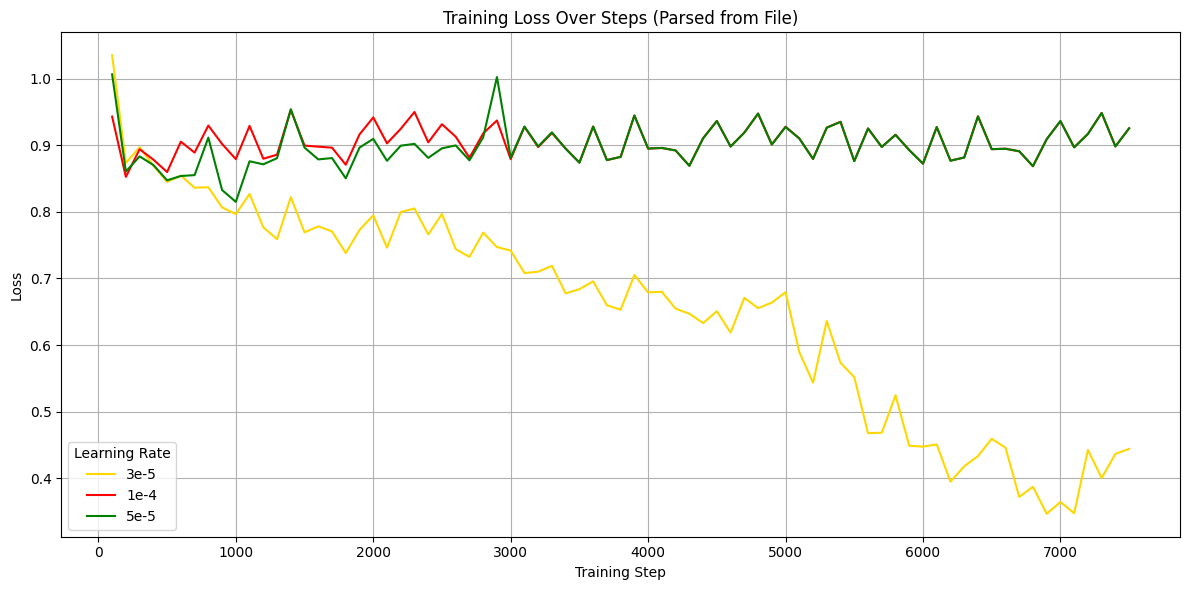

In [20]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

lr_map = {
    "0.0001": "1e-4",
    "5e-05": "5e-5",
    "3e-05": "3e-5",
    "3e-5": "3e-5",
    "5e-5": "5e-5",
    "1e-4": "1e-4"
}

with open(logs_3ep_path, "r") as file:
    log_text = file.read()
    
loss_entries = []
current_lr = None
for line in log_text.splitlines():
    
	if "Running with LR=" in line:
		raw_lr = line.split("Running with LR=")[-1].strip().lower()
		current_lr = lr_map.get(raw_lr, raw_lr)


	match = re.search(r"\[Epoch (\d+) \| Step (\d+)\] loss=([\d.]+)", line)
	if match and current_lr:
		epoch = int(match.group(1))
		step = int(match.group(2))
		global_step = (epoch - 1) * 2500 + step
		loss = float(match.group(3))
		loss_entries.append((global_step, loss, current_lr, epoch))

df_logs = pd.DataFrame(loss_entries, columns=["Step", "Loss", "Learning Rate", "Epoch"])

color_palette = {
    "1e-4": "red",
    "3e-5": "gold",
    "5e-5": "green",
    "0.0001": "red",  # 1e-4
    "0.00005": "green",  # 5e-5
    "0.00003": "gold"  # 3e-5
}

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_logs, x="Step", y="Loss", hue="Learning Rate", palette=color_palette)
plt.title("Training Loss Over Steps (Parsed from File)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(os.path.dirname(logs_3ep_path), "training_loss_plot.png")
plt.savefig(plot_path)
plt.show()

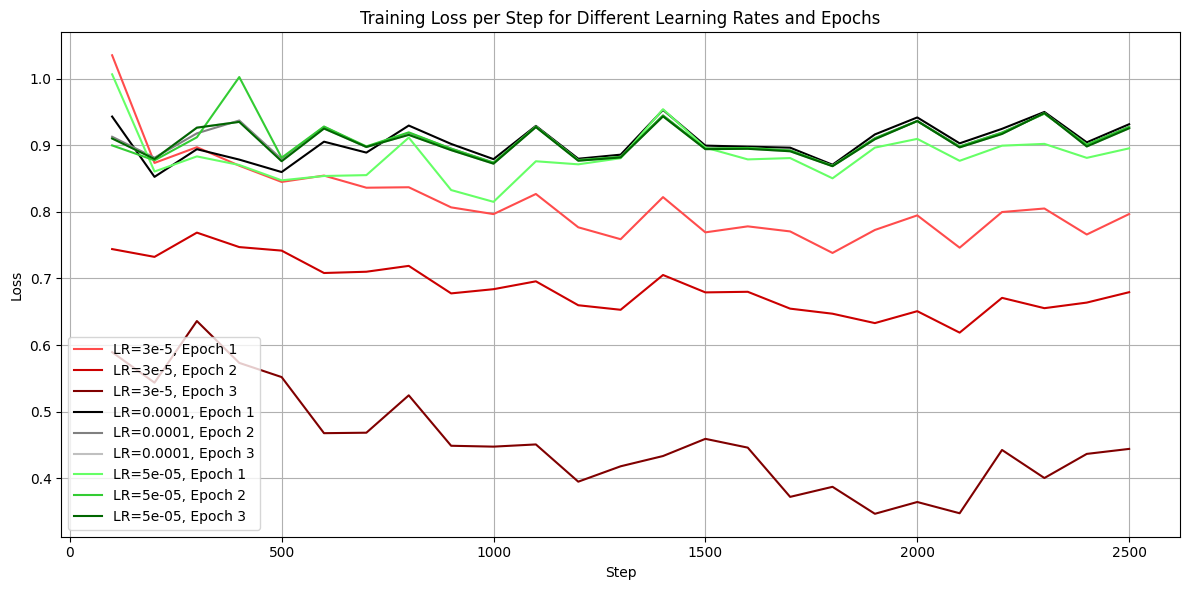

In [24]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

with open(logs_3ep_path, "r") as f:
    log_text = f.read()

pattern_lr = r"Running with LR=([0-9.e-]+)"
pattern_loss = r"\[Epoch (\d+) \| Step (\d+)\] loss=([0-9.]+)"

entries = re.split(pattern_lr, log_text)[1:]  
loss_data = defaultdict(lambda: defaultdict(list))  # lr -> epoch -> list of (step, loss)

for i in range(0, len(entries), 2):
    lr = entries[i]
    log = entries[i + 1]
    for match in re.finditer(pattern_loss, log):
        epoch, step, loss = int(match[1]), int(match[2]), float(match[3])
        loss_data[lr][epoch].append((step, loss))

# custom colors per learning rate
color_shades = {
    "3e-5": ["#ff4c4c", "#cc0000", "#800000"],      # red shades
    "1e-4": ["#4ca3ff", "#0066cc", "#003366"],    # blue shades
    "5e-05": ["#66ff66", "#33cc33", "#006600"],     # green shades
}

plt.figure(figsize=(12, 6))

for lr, epochs in loss_data.items():
    for idx, (epoch, data) in enumerate(sorted(epochs.items())):
        steps, losses = zip(*sorted(data))
        color = color_shades.get(lr, ["black", "gray", "silver"])[idx % 3]  # fallback
        plt.plot(steps, losses, label=f"LR={lr}, Epoch {epoch}", color=color)

plt.title("Training Loss per Step for Different Learning Rates and Epochs")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(os.path.dirname(logs_3ep_path), "training_loss_plot_per_epoch.png")
plt.savefig(plot_path)
plt.show()


## Result: We are choosing learning rate lr = 3e-5

In [ ]:
lr = 3e-5
print("-"*60)
print(f"Running with LR={lr}")
val_acc = train_stage1_claim_only(
	multifc_path=multifc_path,
	output_path=output_claim_only_path,
	roberta_name=MODEL_NAME,
	batch_size=8,
	freeze_until=10,
	lr=lr,
	epochs=10, # run for 10 epochs
	max_len=128,
	nr_model=3 # save model as index = 3
)
if val_acc > best_acc:
	best_acc = val_acc
print("-"*60)
print(f"--> Final val_acc: {val_acc:.4f}")
print("-"*60)
print()
print()